In [2]:
import pandas as pd 

df = pd.read_csv("cleaned_data.csv")

In [3]:
df.head()


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 805549 entries, 0 to 805548
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Invoice      805549 non-null  int64  
 1   StockCode    805549 non-null  object 
 2   Description  805549 non-null  object 
 3   Quantity     805549 non-null  int64  
 4   InvoiceDate  805549 non-null  object 
 5   Price        805549 non-null  float64
 6   Customer ID  805549 non-null  int64  
 7   Country      805549 non-null  object 
 8   TotalPrice   805549 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 55.3+ MB


In [8]:
#Converting InvoiceDate to actual datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [9]:
# Overall business snapshot
print(f"Unique customers: {df['Customer ID'].nunique()}")
print(f"Unique invoices (orders): {df['Invoice'].nunique()}")
print(f"Total revenue: £{df['TotalPrice'].sum():,.2f}")
print(f"Date range: {df['InvoiceDate'].min()} to {df['InvoiceDate'].max()}")

# Revenue by country (top 10)
df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Unique customers: 5878
Unique invoices (orders): 36969
Total revenue: £17,743,429.18
Date range: 2009-12-01 07:45:00 to 2011-12-09 12:50:00


Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: TotalPrice, dtype: float64

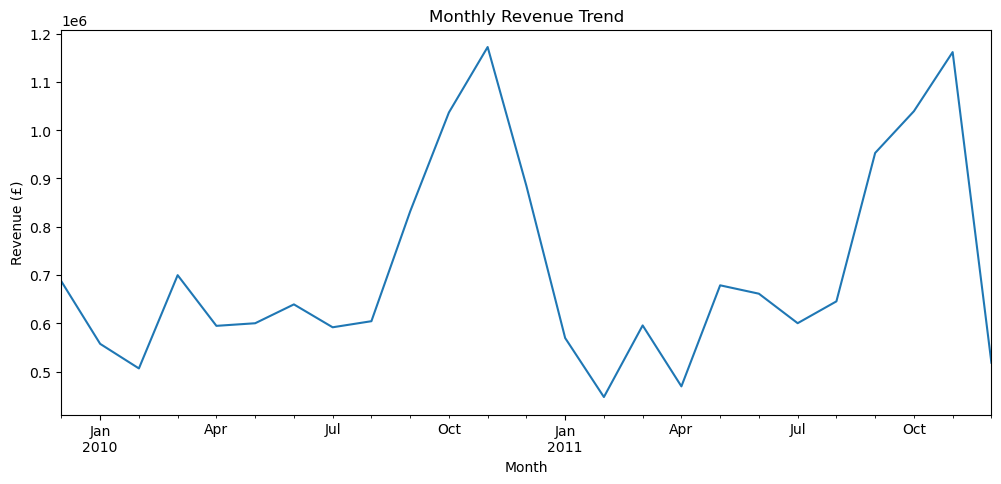

In [10]:
import matplotlib.pyplot as plt

# Revenue trend over time (monthly)
monthly_revenue = df.set_index('InvoiceDate').resample('ME')['TotalPrice'].sum()

plt.figure(figsize=(12,5))
monthly_revenue.plot()
plt.title('Monthly Revenue Trend')
plt.ylabel('Revenue (£)')
plt.xlabel('Month')
plt.show()

In [11]:
# Top 10 products by revenue
df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

Description
REGENCY CAKESTAND 3 TIER              286486.30
WHITE HANGING HEART T-LIGHT HOLDER    252072.46
PAPER CRAFT , LITTLE BIRDIE           168469.60
Manual                                152340.57
JUMBO BAG RED RETROSPOT               136980.08
ASSORTED COLOUR BIRD ORNAMENT         127074.17
POSTAGE                               126563.04
PARTY BUNTING                         103880.23
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
PAPER CHAIN KIT 50'S CHRISTMAS         79594.33
Name: TotalPrice, dtype: float64

In [12]:
# Distribution of order values — helps you understand what "average" and "high" order value even means for this business
df.groupby('Invoice')['TotalPrice'].sum().describe()

count     36969.000000
mean        479.954264
std        1374.990573
min           0.380000
25%         160.800000
50%         305.250000
75%         489.260000
max      168469.600000
Name: TotalPrice, dtype: float64